In [1]:
library(repr)
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)
options(bitmapType = 'cairo')
library(showtext)
font_add_google("Lato", "lato")
font_add_google(name = "Roboto", family = "roboto")
showtext_opts(dpi = 300)
showtext_auto()

Loading required package: sysfonts

Loading required package: showtextdb



In [3]:
df <- read_csv("median_io_group_gaze.csv")
df <- df |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        PID = factor(PID)
    ) |>
    rename(
        building_location = inside,
        group = category
    )

Rows: 1829 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (4): PID, inside, GroupCount, median_clusterDuration

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
# df |> ggplot(aes(x = group, y = median_clusterDuration, color = building_location)) +
#  geom_point(position = position_dodge(0.4)) +
#  theme_minimal()
df |> head()

PID,hitObjectColliderName,group,building_location,GroupCount,median_clusterDuration
<fct>,<chr>,<chr>,<fct>,<dbl>,<dbl>
4003,Building_100,peripheral,outside,10,0.4109216
4003,Building_101,peripheral,outside,8,0.4438699
4003,Building_102,peripheral,outside,15,0.3658845
4003,Building_131,peripheral,outside,2,0.5775331
4003,Building_132,peripheral,outside,3,0.3659341
4003,Building_139,peripheral,outside,7,0.3102803


Warning message:
“Removed 55 rows containing non-finite outside the scale range
(`stat_density()`).”


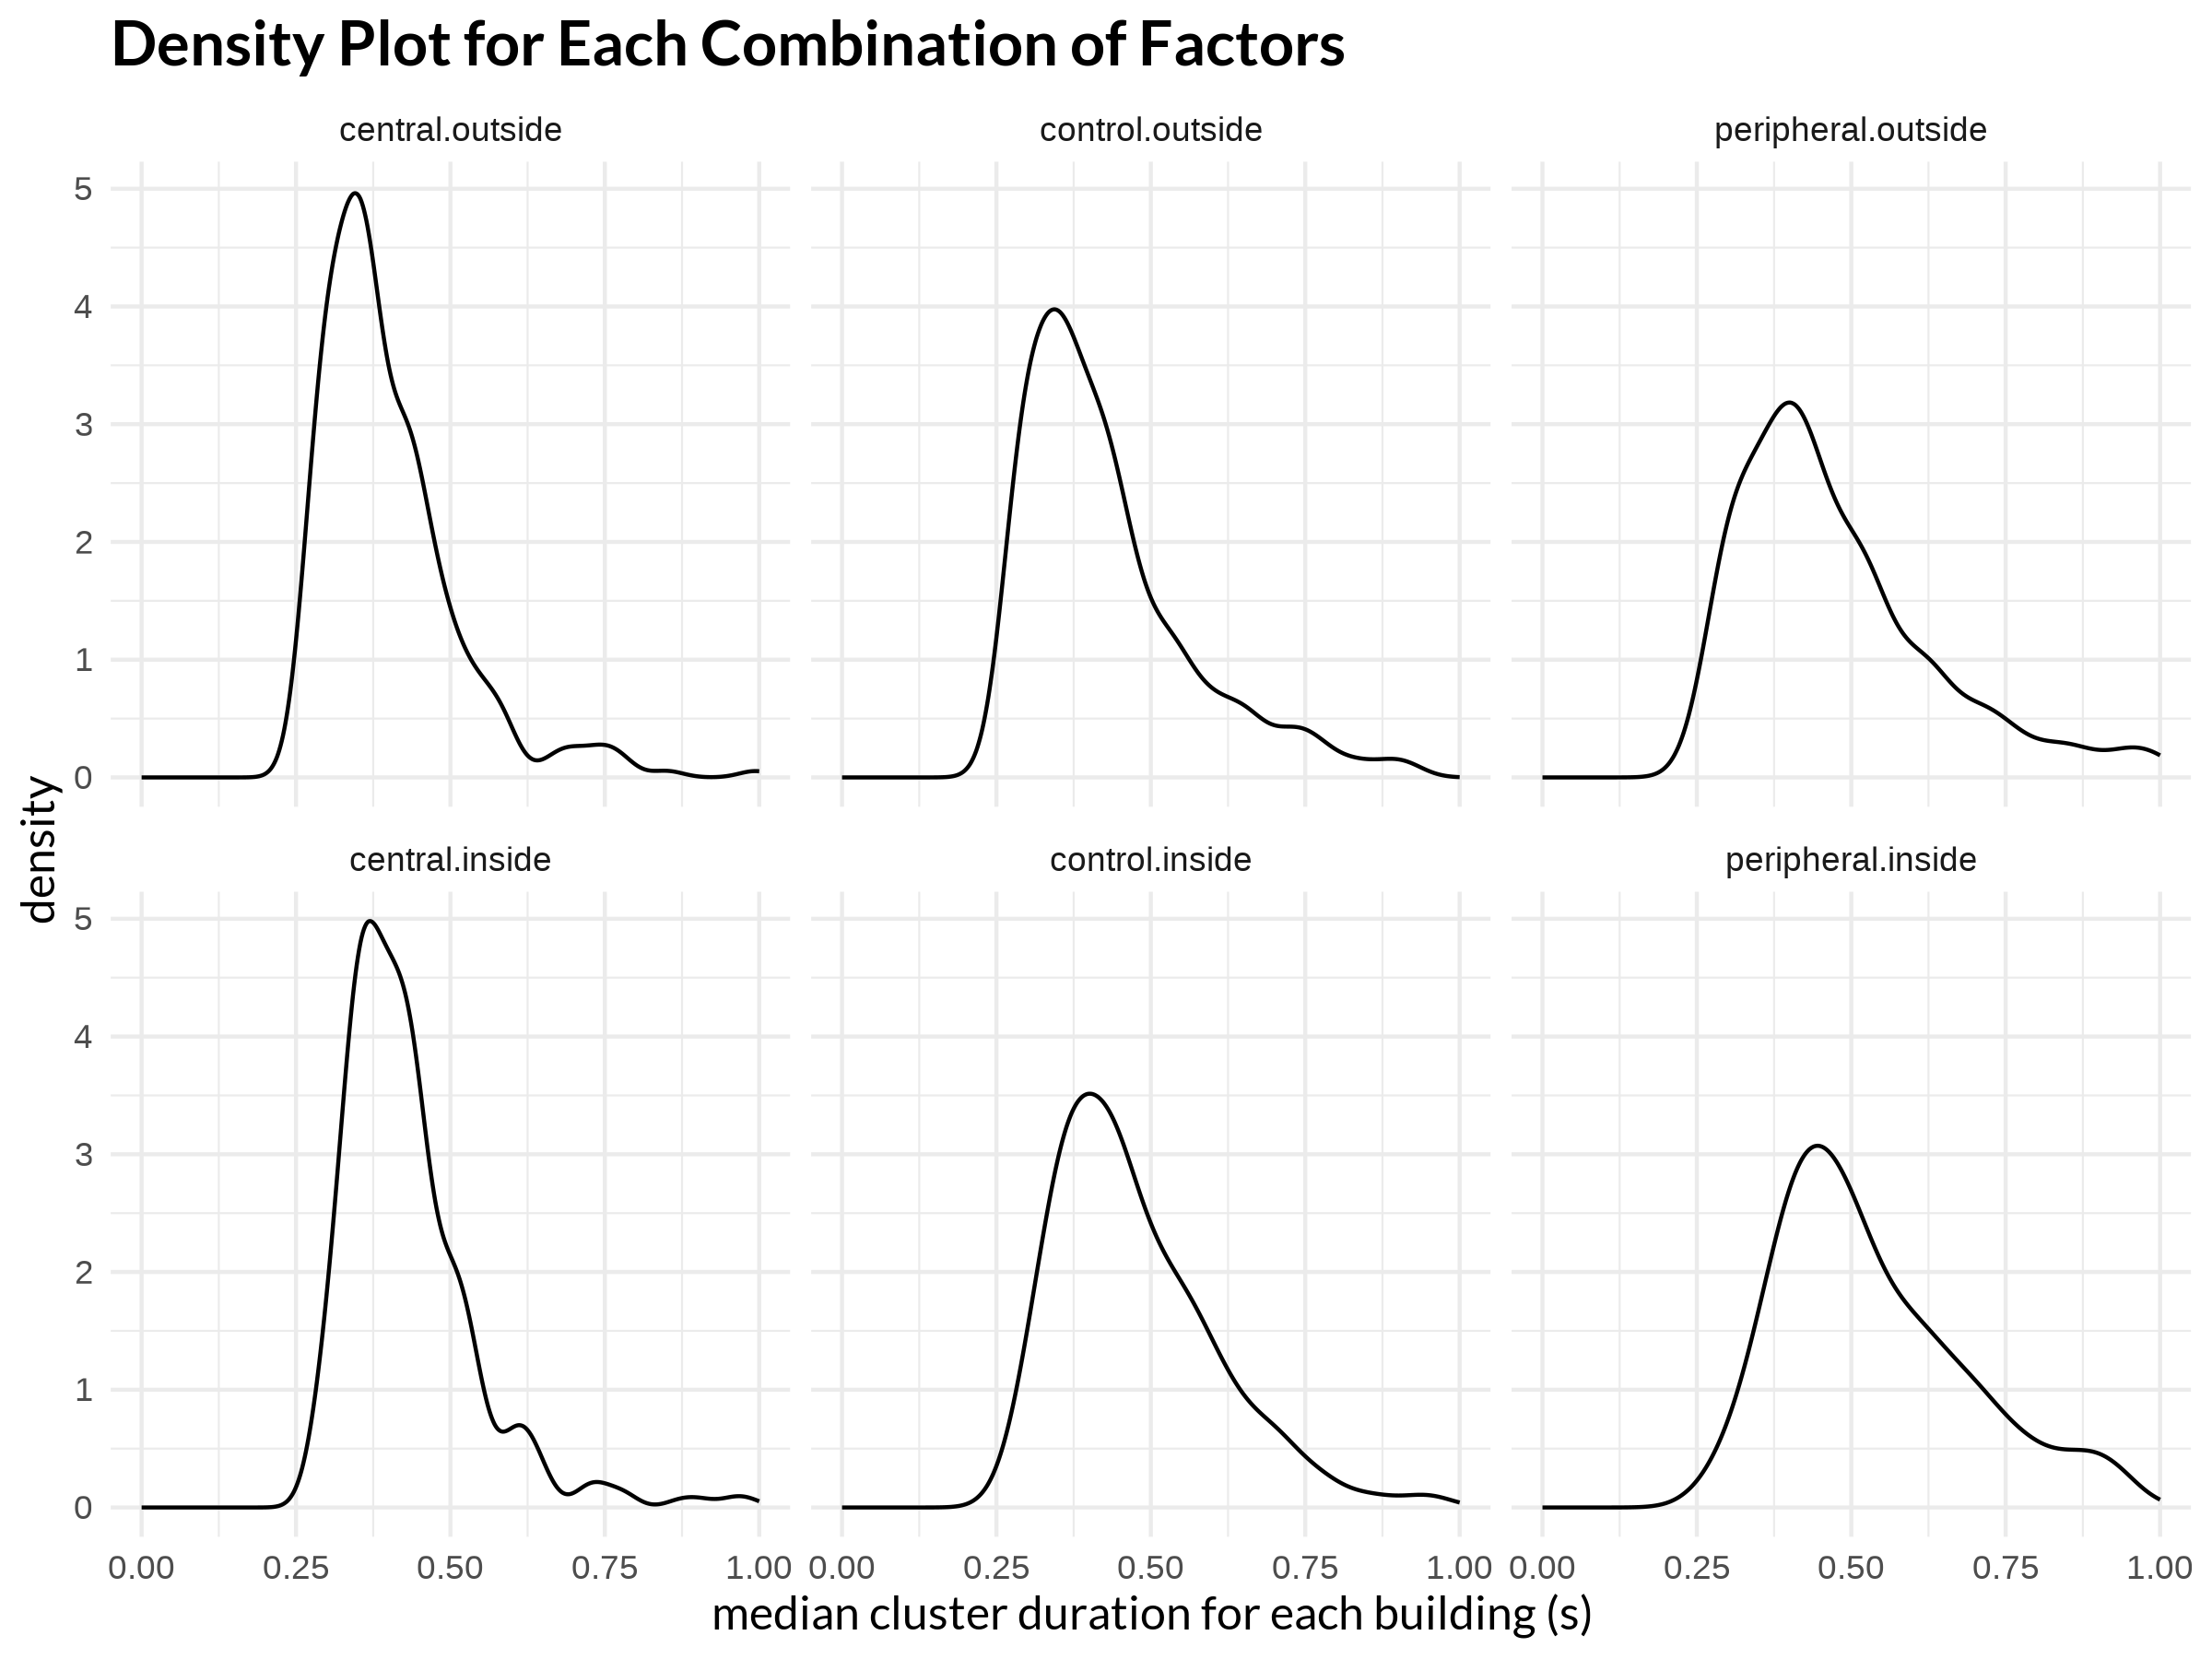

In [5]:
fig <- df |>
  ggplot(aes(x = median_clusterDuration)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  xlim(0, 1) +
  facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
  theme_minimal() +
  labs(title = "Density Plot for Each Combination of Factors",
       x = "median cluster duration for each building (s)",
       y = "density") +
  theme(
    plot.title = element_text(family = "lato", size = 16, face = "bold"),
    axis.title.x = element_text(family = "lato", size = 12),
    axis.title.y = element_text(family = "lato", size = 12)
   )
fig
#ggsave("naisu_only_location.svg", fig)

In [6]:
library(lme4)
library(emmeans)
library(performance)

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



In [7]:
# Fit a generalized linear mixed model (GLMM) using glmer
# Assuming a dataset 'data' with a binary response variable 'y', 
# a fixed effect 'x', and a random effect 'group'
df_filter <- df %>% filter(median_clusterDuration < 3)
model <- glmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df, Gamma(link = "inverse"))
# model0 <- glmer(median_clusterDuration ~ 1 + (1 | PID) + (1| hitObjectColliderName), data = df, Gamma(link = "inverse"))

In [8]:
df_summary <- df %>%
    group_by(group) %>%
    summarise(
        med_med = median(median_clusterDuration),
    ) %>%
    ungroup()

df_summary

group,med_med
<chr>,<dbl>
central,0.3941432
control,0.4221466
peripheral,0.4827673


In [9]:
model

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( inverse )
Formula: median_clusterDuration ~ building_location + group + (1 | PID) +  
    (1 | hitObjectColliderName)
   Data: df
       AIC        BIC     logLik  -2*log(L)   df.resid 
-1865.4538 -1826.8732   939.7269 -1879.4538       1822 
Random effects:
 Groups                Name        Std.Dev.
 hitObjectColliderName (Intercept) 0.2845  
 PID                   (Intercept) 0.1202  
 Residual                          0.3688  
Number of obs: 1829, groups:  hitObjectColliderName, 127; PID, 24
Fixed Effects:
            (Intercept)  building_locationinside             groupcontrol  
                 2.6867                  -0.3545                  -0.1874  
        groupperipheral  
                -0.4871  

In [10]:
anova(model)
library(car)
Anova(model)
anova(model)

,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
building_location,1,3.598557,3.598557,26.46256
group,2,5.930017,2.965008,21.80367


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
building_location,13.52985,1,2.347989e-04
group,26.85680,2,1.472722e-06


,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
building_location,1,3.598557,3.598557,26.46256
group,2,5.930017,2.965008,21.80367


In [11]:
# Create a reference grid
ref_grid <- ref_grid(model)
02
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ group)
emm_eff <- emmeans(model, ~ group)
eff_size(emm_eff, sigma = sigma(model)*sqrt(2), edf = df.residual(model))

# View results
summary(emm)
pairs(emm, adjust = "tukey")
r2_nakagawa(model)


[1] 2

 contrast             effect.size    SE  df asymp.LCL asymp.UCL
 central - control          0.359 0.180 Inf    0.0072     0.711
 central - peripheral       0.934 0.182 Inf    0.5771     1.291
 control - peripheral       0.575 0.183 Inf    0.2163     0.933

Results are averaged over the levels of: building_location 
sigma used for effect sizes: 0.5215 
Confidence level used: 0.95 

,group,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,central,0.4004916,0.01403735,Inf,0.3729789,0.4280043
2,control,0.4331715,0.01687316,Inf,0.4001007,0.4662423
3,peripheral,0.4982905,0.02314886,Inf,0.4529195,0.5436614


 contrast             estimate     SE  df z.ratio p.value
 central - control     -0.0327 0.0166 Inf  -1.972  0.1191
 central - peripheral  -0.0978 0.0210 Inf  -4.646  <.0001
 control - peripheral  -0.0651 0.0216 Inf  -3.013  0.0073

Results are averaged over the levels of: building_location 
P value adjustment: tukey method for comparing a family of 3 estimates 

# R2 for Mixed Models

  Conditional R2: 0.549
     Marginal R2: 0.233

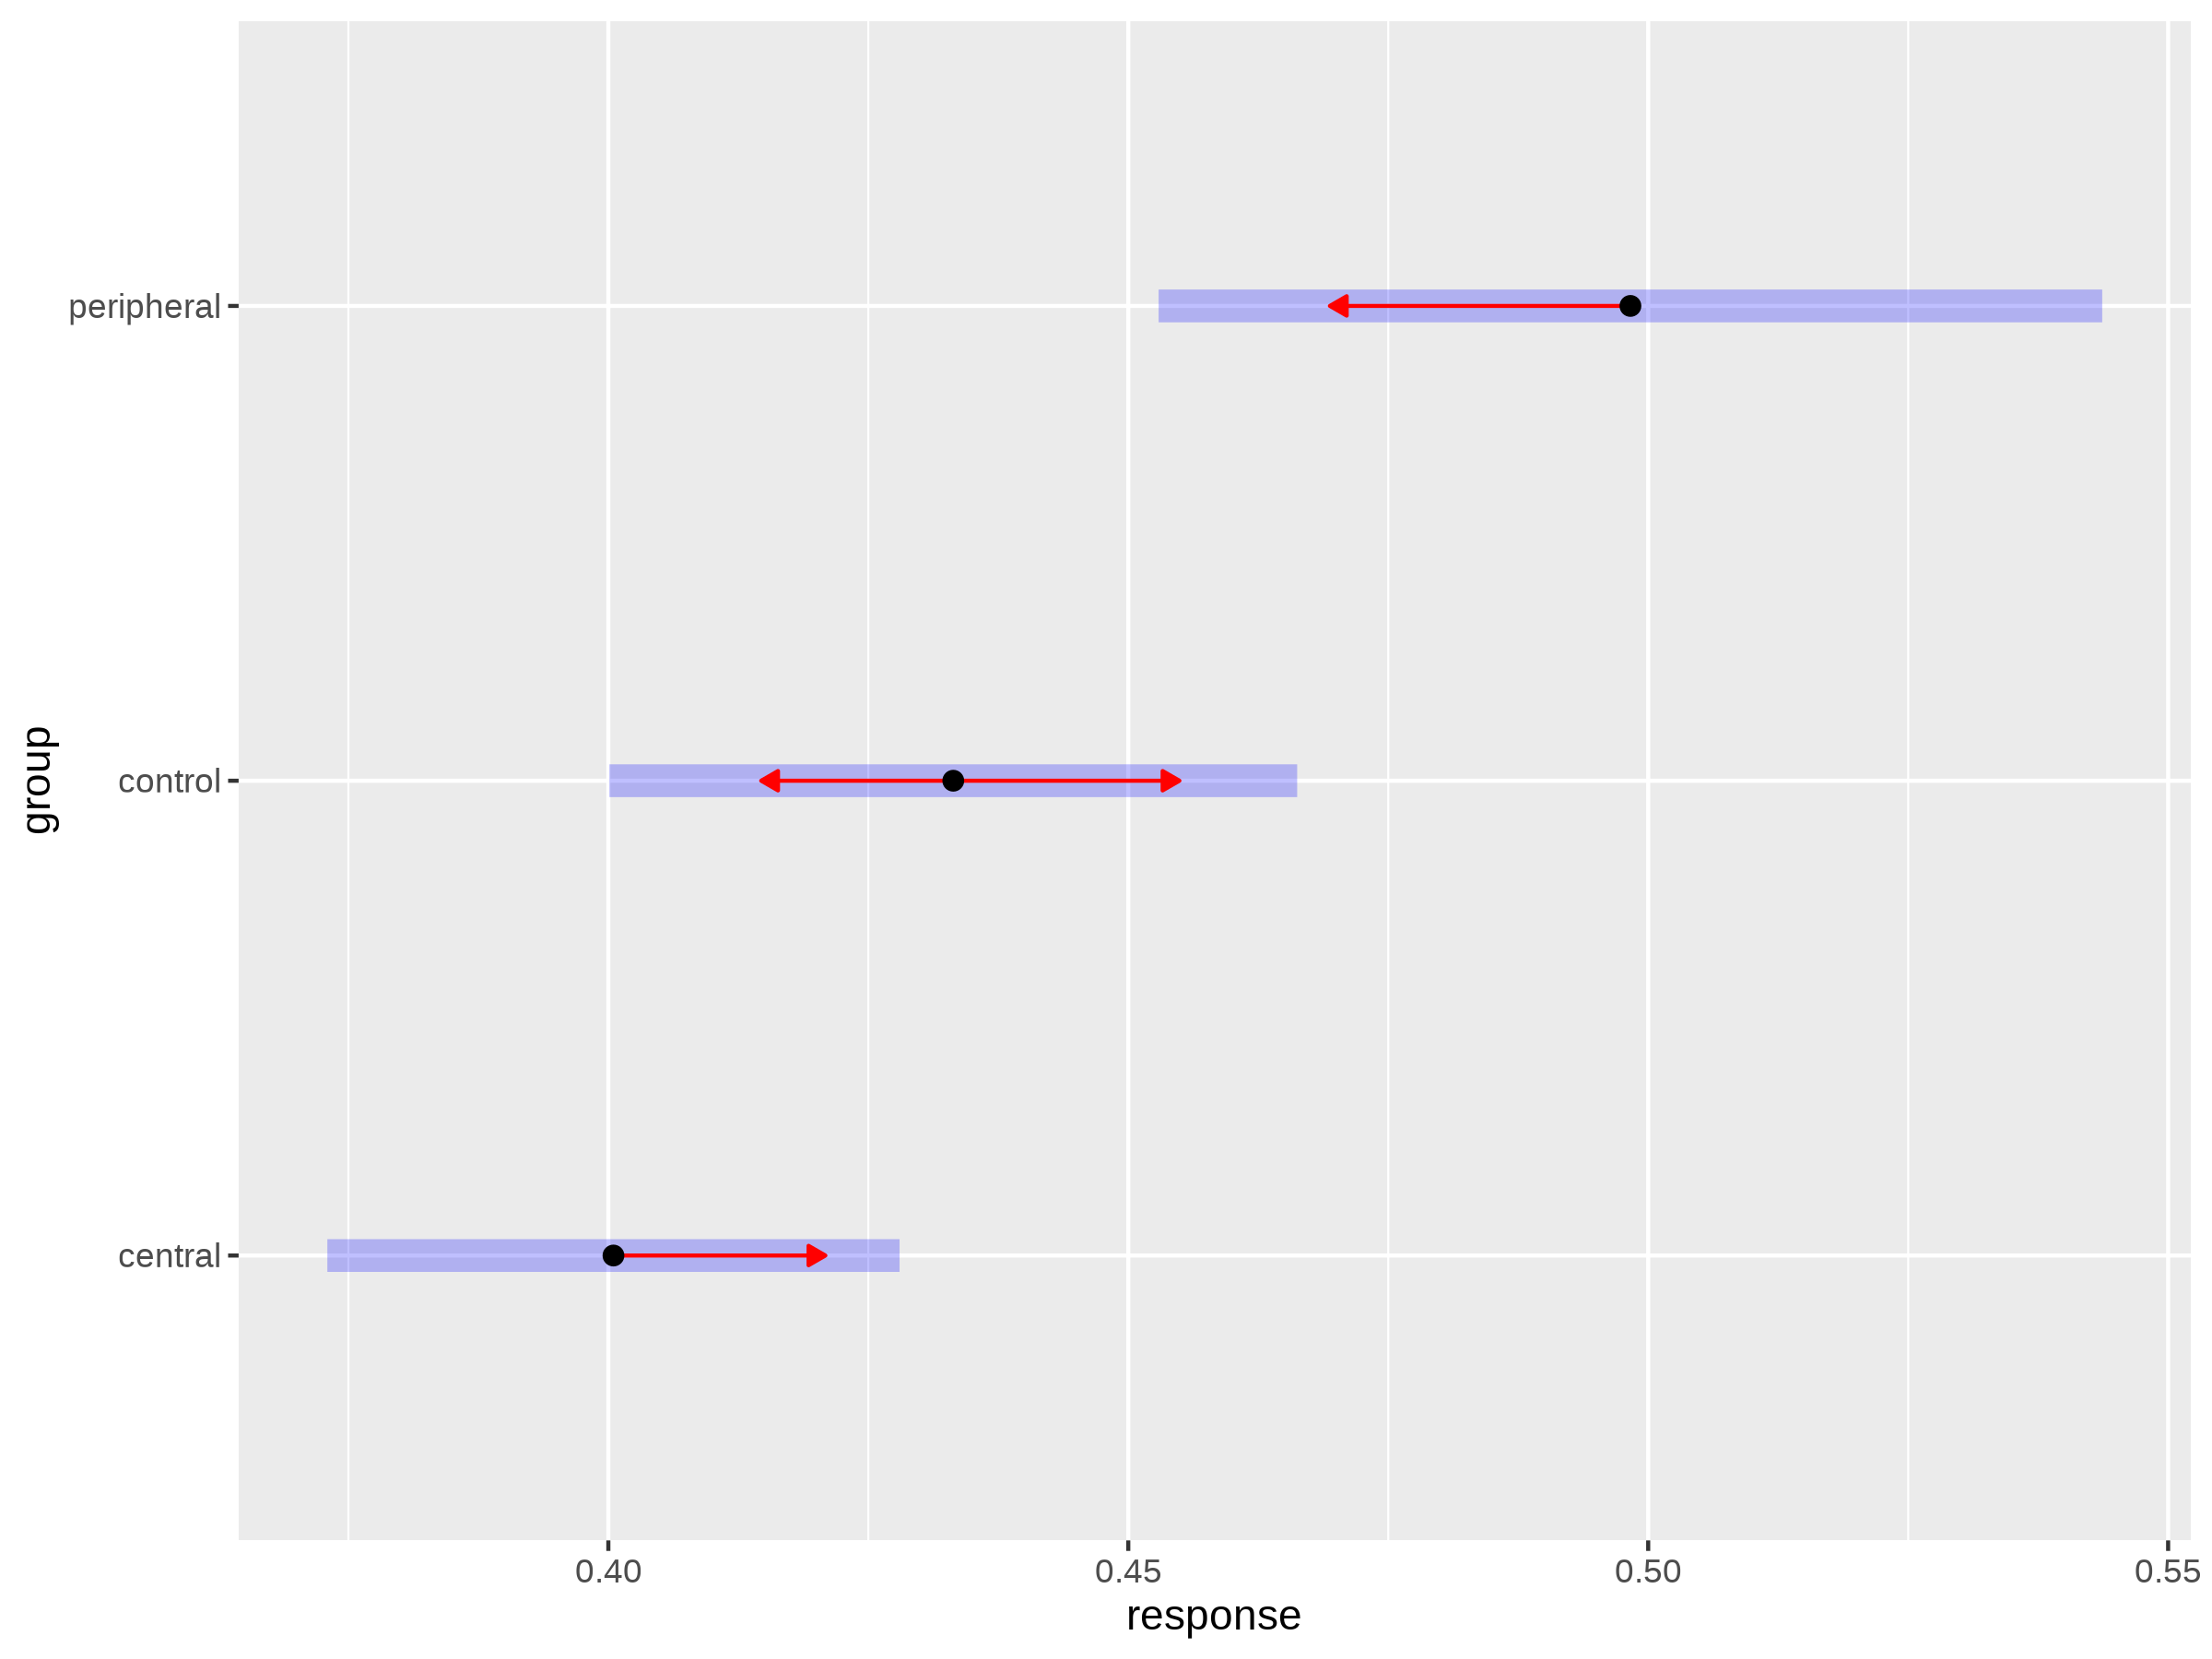

In [12]:
plot(emm, comparisons = TRUE)

In [13]:
r2_nakagawa(model, by_group = TRUE)
r2_nakagawa(model)
icc(model)
icc(model, by_group = TRUE)

,Level,R2
,<chr>,<dbl>
,Level 1,0.01841683
PID,PID,0.53912946
hitObjectColliderName,hitObjectColliderName,0.12725534


# R2 for Mixed Models

  Conditional R2: 0.549
     Marginal R2: 0.233

ICC_adjusted,ICC_conditional,ICC_unadjusted
<dbl>,<dbl>,<dbl>
0.4123171,0.3162221,0.3162221


Group,ICC
<chr>,<dbl>
hitObjectColliderName,0.3498808
PID,0.0624363


In [14]:
library(brms)
bayes_model <- brm(
    median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName),
    data = df,
    family = "gamma"
)

Loading required package: Rcpp

Loading 'brms' package (version 2.22.0). Useful instructions
can be found by typing help('brms'). A more detailed introduction
to the package is available through vignette('brms_overview').


Attaching package: ‘brms’


The following object is masked from ‘package:lme4’:

    ngrps


The following object is masked from ‘package:stats’:

    ar


Compiling Stan program...

Start sampling




SAMPLING FOR MODEL 'anon_model' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.000304 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 3.04 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 6.464 seconds (Warm-up)
Chain 1:                2.098 seconds (Sampling)
Chain 1:                8.5

 Family: gamma 
  Links: mu = log; shape = identity 
Formula: median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName) 
   Data: df (Number of observations: 1829) 
  Draws: 4 chains, each with iter = 2000; warmup = 1000; thin = 1;
         total post-warmup draws = 4000

Multilevel Hyperparameters:
~hitObjectColliderName (Number of levels: 127) 
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)     0.15      0.01     0.13     0.18 1.00     1155     1907

~PID (Number of levels: 24) 
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)     0.07      0.02     0.05     0.11 1.00     1376     1998

Regression Coefficients:
                        Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
Intercept                  -0.94      0.04    -1.02    -0.87 1.00     1149
building_locationinside     0.14      0.03     0.08     0.21 1.00      890
groupcontrol                0.08      0

Using 10 posterior draws for ppc type 'dens_overlay' by default.



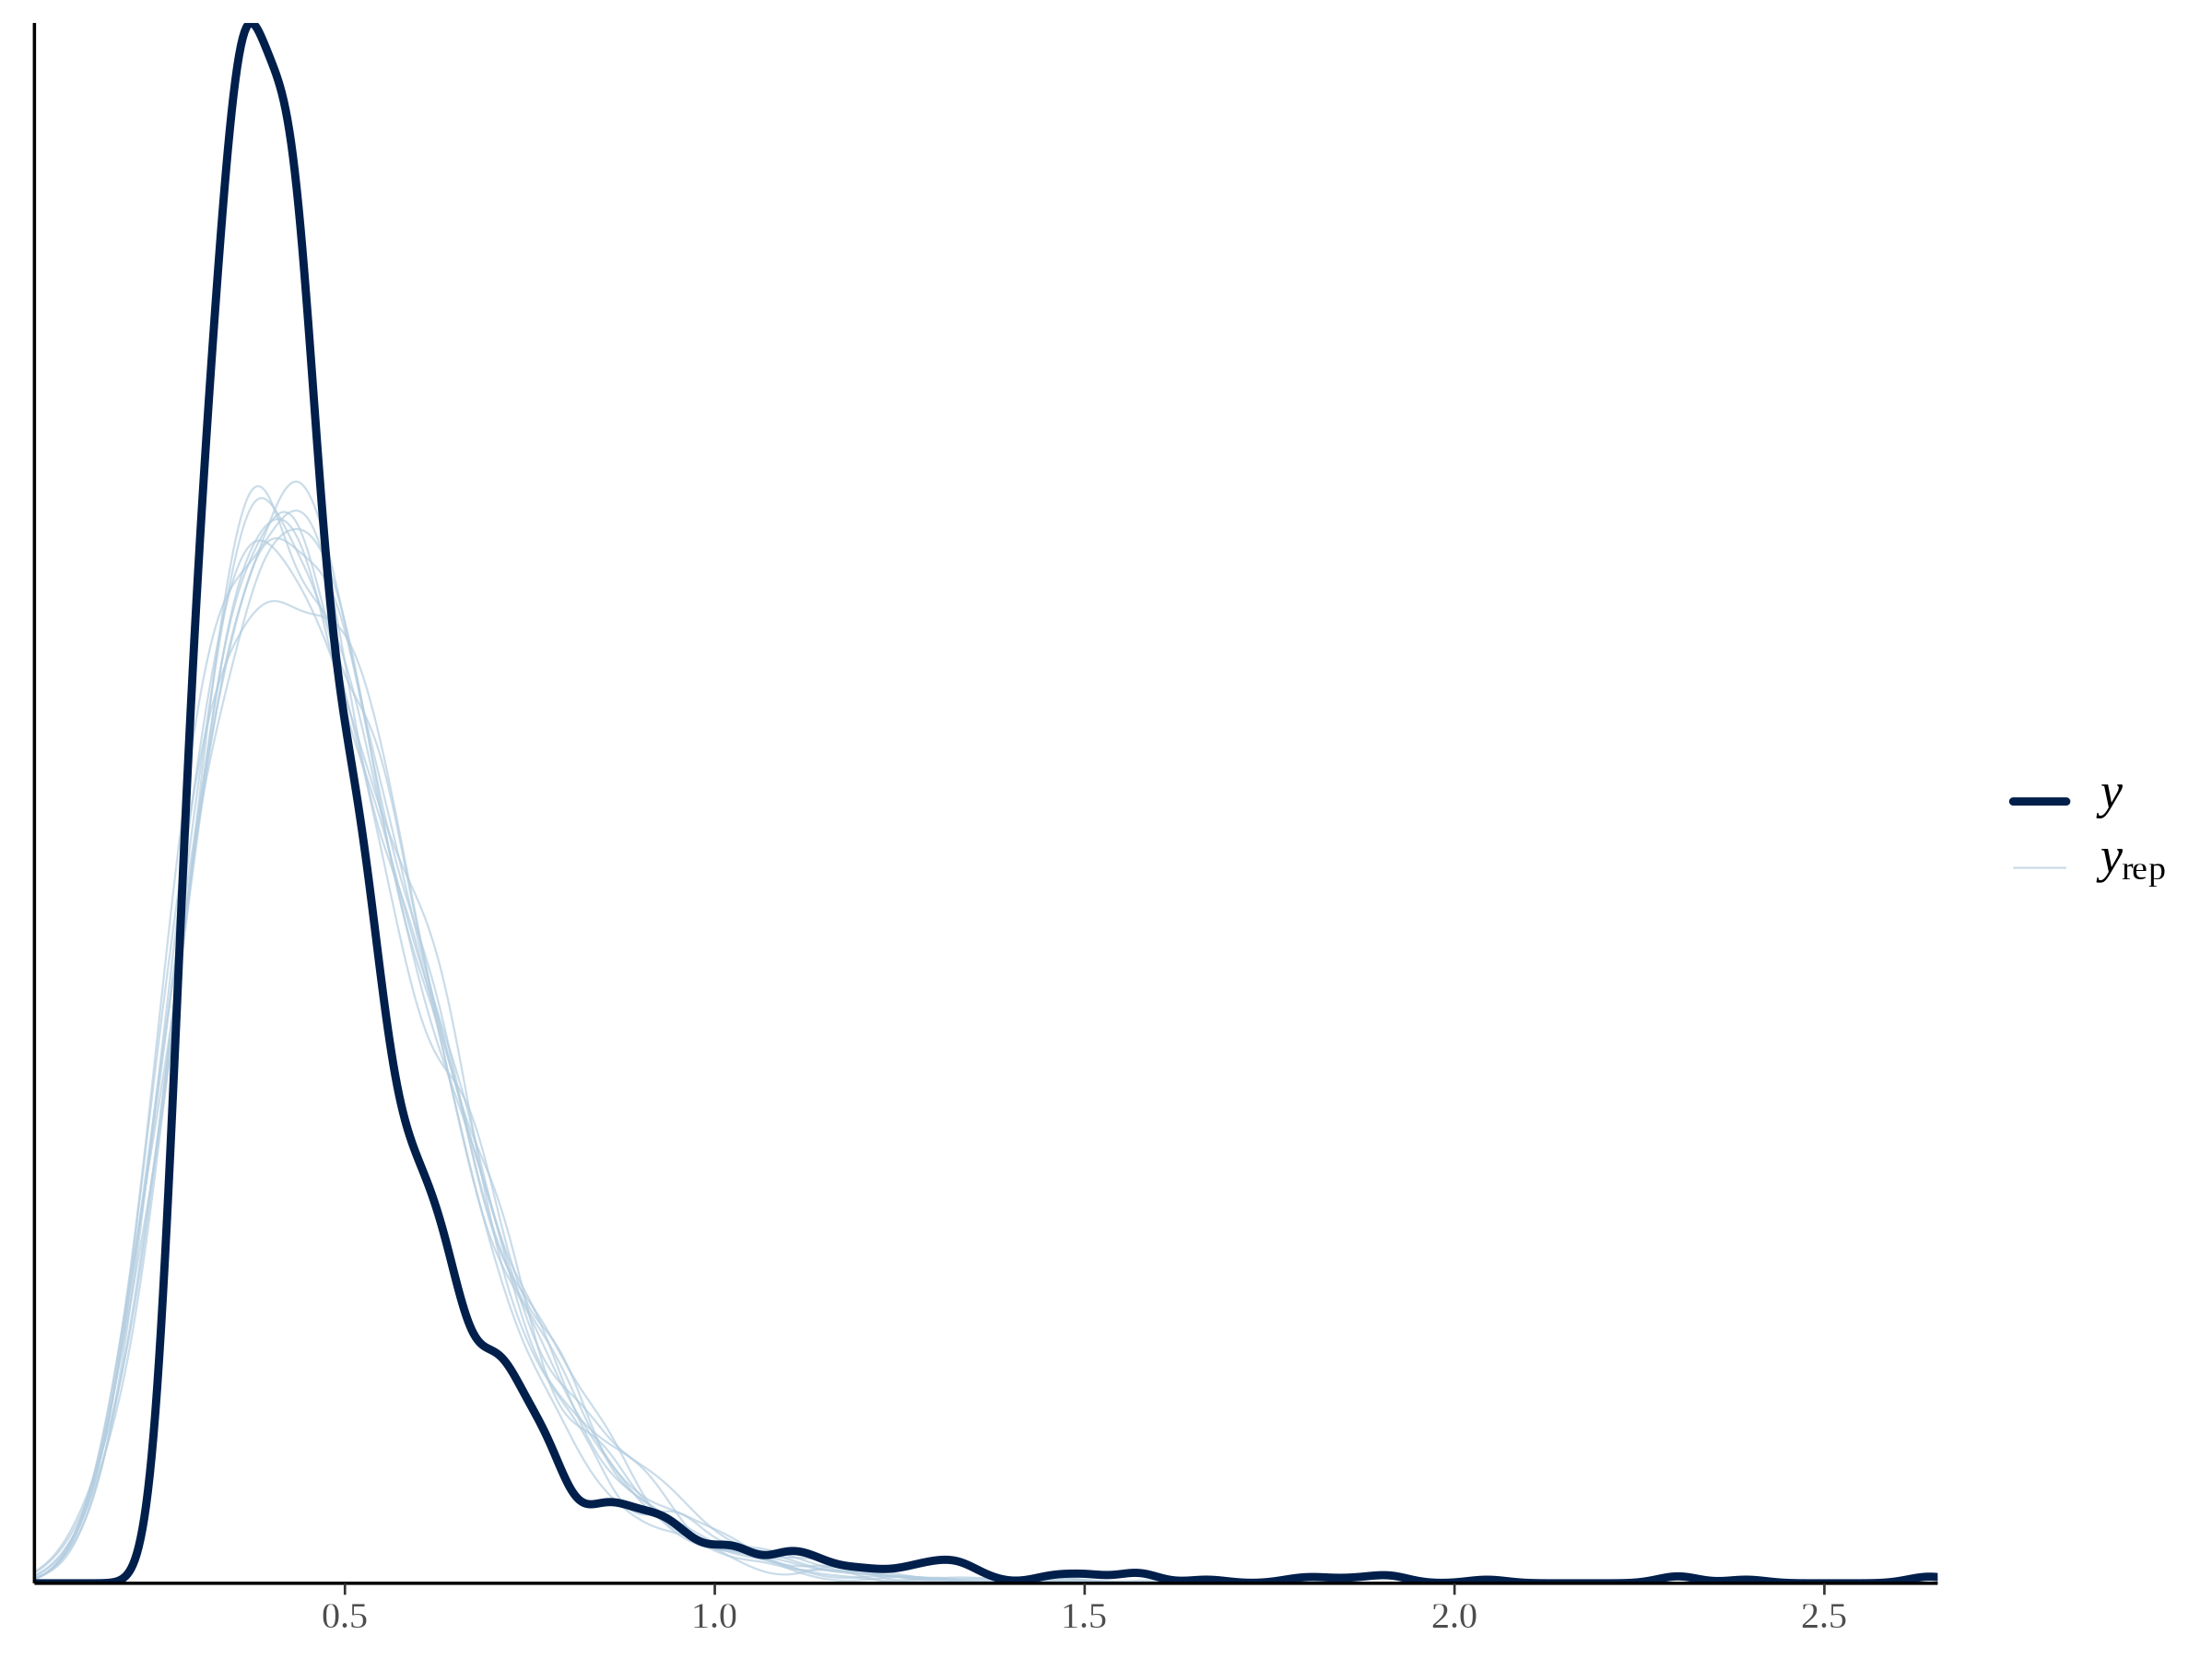

In [15]:
bayes_model
pp_check(bayes_model)

In [16]:
df_node <- read_csv("io_node_group_gaze.csv")

df_node <- df_node |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        hitObjectColliderName = factor(hitObjectColliderName),
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control"))
    ) |>
    rename(
        building_location = inside,
        group = category,
        building = hitObjectColliderName,
        duration = clusterDuration
    )

df_node |> head()


Rows: 17925 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (6): clusterID, sampleNr, clusterDuration, PID, inside, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


clusterID,sampleNr,duration,building,PID,group,building_location,connections
<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<dbl>
2,121,1.3477349,TaskBuilding_35,4003,peripheral,inside,17
7,35,0.3888457,Building_166,4003,peripheral,inside,12
9,39,0.4330869,Building_168,4003,peripheral,inside,11
10,33,0.3671408,TaskBuilding_42,4003,peripheral,inside,12
12,57,0.6329131,Building_166,4003,peripheral,inside,12
13,56,0.6199913,Building_166,4003,peripheral,inside,12


In [17]:
pid_order <- df_node |> arrange(group) |> distinct(PID) |> pull(PID)

`summarise()` has grouped output by 'PID', 'building', 'group',
'building_location'. You can override using the `.groups` argument.


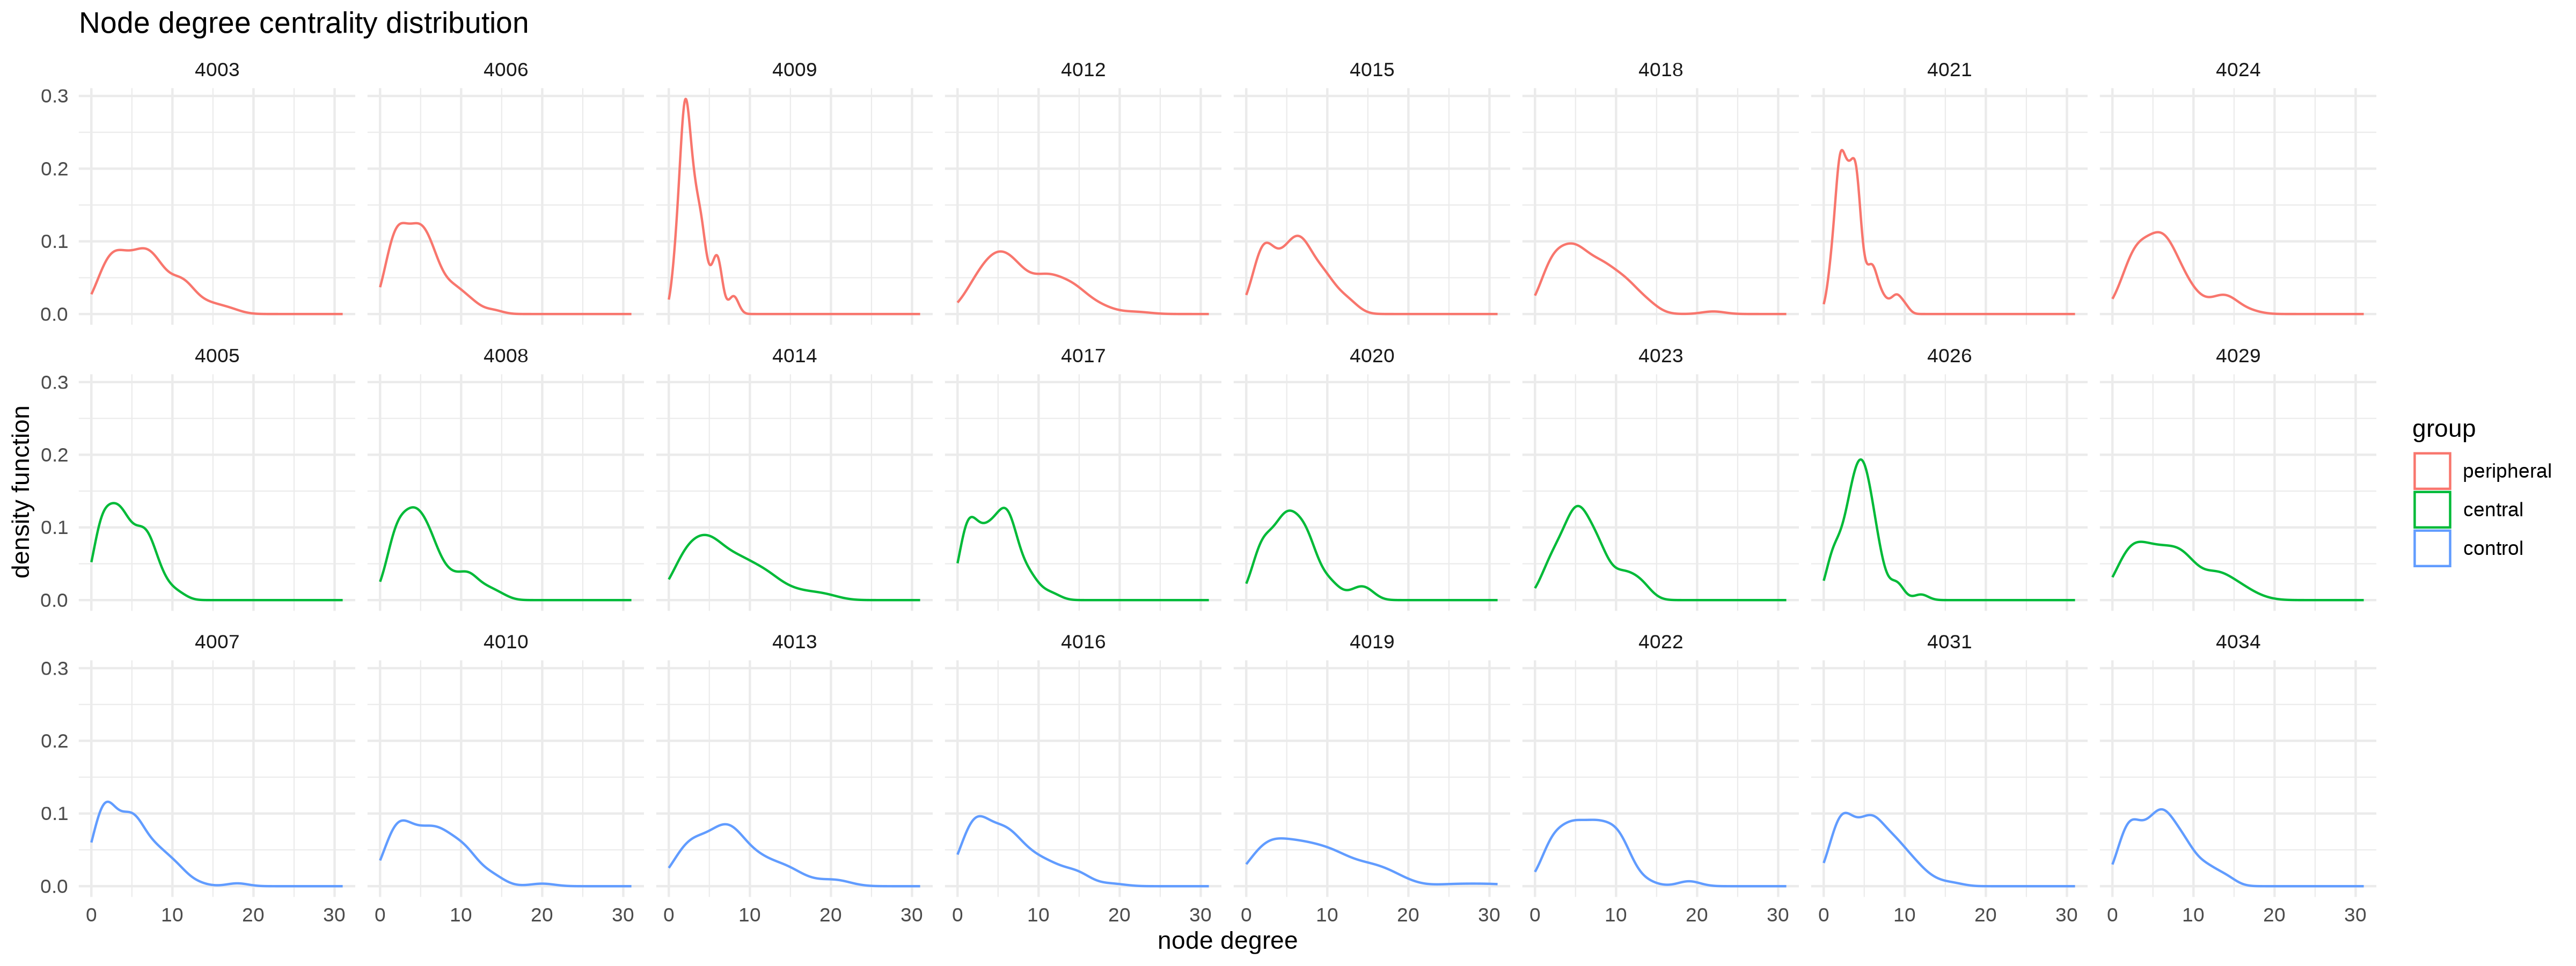

In [18]:
options(repr.plot.width=16, repr.plot.height=6, repr.plot.res = 600)
fig <- df_node |>
    group_by(PID, building, group, building_location, connections) |>
    summarise(median_duration = median(duration)) |>
    ungroup() |>
    ggplot(aes(x = connections, group = PID, color = group)) +
      # geom_histogram(bins = 50) +
      geom_density(alpha = 0.6) +  # Adjust alpha for transparency
      facet_wrap(
          ~ factor(PID, pid_order),
          ncol = 8
      ) +  # Facet by the interaction of the two factors
      theme_minimal() +
      labs(title = "Node degree centrality distribution",
           x = "node degree",
           y = "density function")
fig
ggsave("sim_indiv_node_degree_dist.svg", fig, width = 16, height = 6, units = "in", dpi = 600)
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)

In [19]:
df_group_node <- df_node |>
    group_by(PID, building, group, building_location, connections) |>
    summarise(median_duration = median(duration)) |>
    ungroup()

`summarise()` has grouped output by 'PID', 'building', 'group',
'building_location'. You can override using the `.groups` argument.


In [20]:
# peripheral central control

group_df_node <- df_node |> group_by(group) |> group_split()

In [21]:
# connections
ks.test(group_df_node[[1]] |> pull(connections), group_df_node[[2]] |> pull(connections))
ks.test(group_df_node[[1]] |> pull(connections), group_df_node[[3]] |> pull(connections))
ks.test(group_df_node[[2]] |> pull(connections), group_df_node[[3]] |> pull(connections))

Warning message in ks.test.default(pull(group_df_node[[1]], connections), pull(group_df_node[[2]], :
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  pull(group_df_node[[1]], connections) and pull(group_df_node[[2]], connections)
D = 0.070928, p-value = 2.091e-12
alternative hypothesis: two-sided


Warning message in ks.test.default(pull(group_df_node[[1]], connections), pull(group_df_node[[3]], :
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  pull(group_df_node[[1]], connections) and pull(group_df_node[[3]], connections)
D = 0.083856, p-value < 2.2e-16
alternative hypothesis: two-sided


Warning message in ks.test.default(pull(group_df_node[[2]], connections), pull(group_df_node[[3]], :
“p-value will be approximate in the presence of ties”



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  pull(group_df_node[[2]], connections) and pull(group_df_node[[3]], connections)
D = 0.15109, p-value < 2.2e-16
alternative hypothesis: two-sided


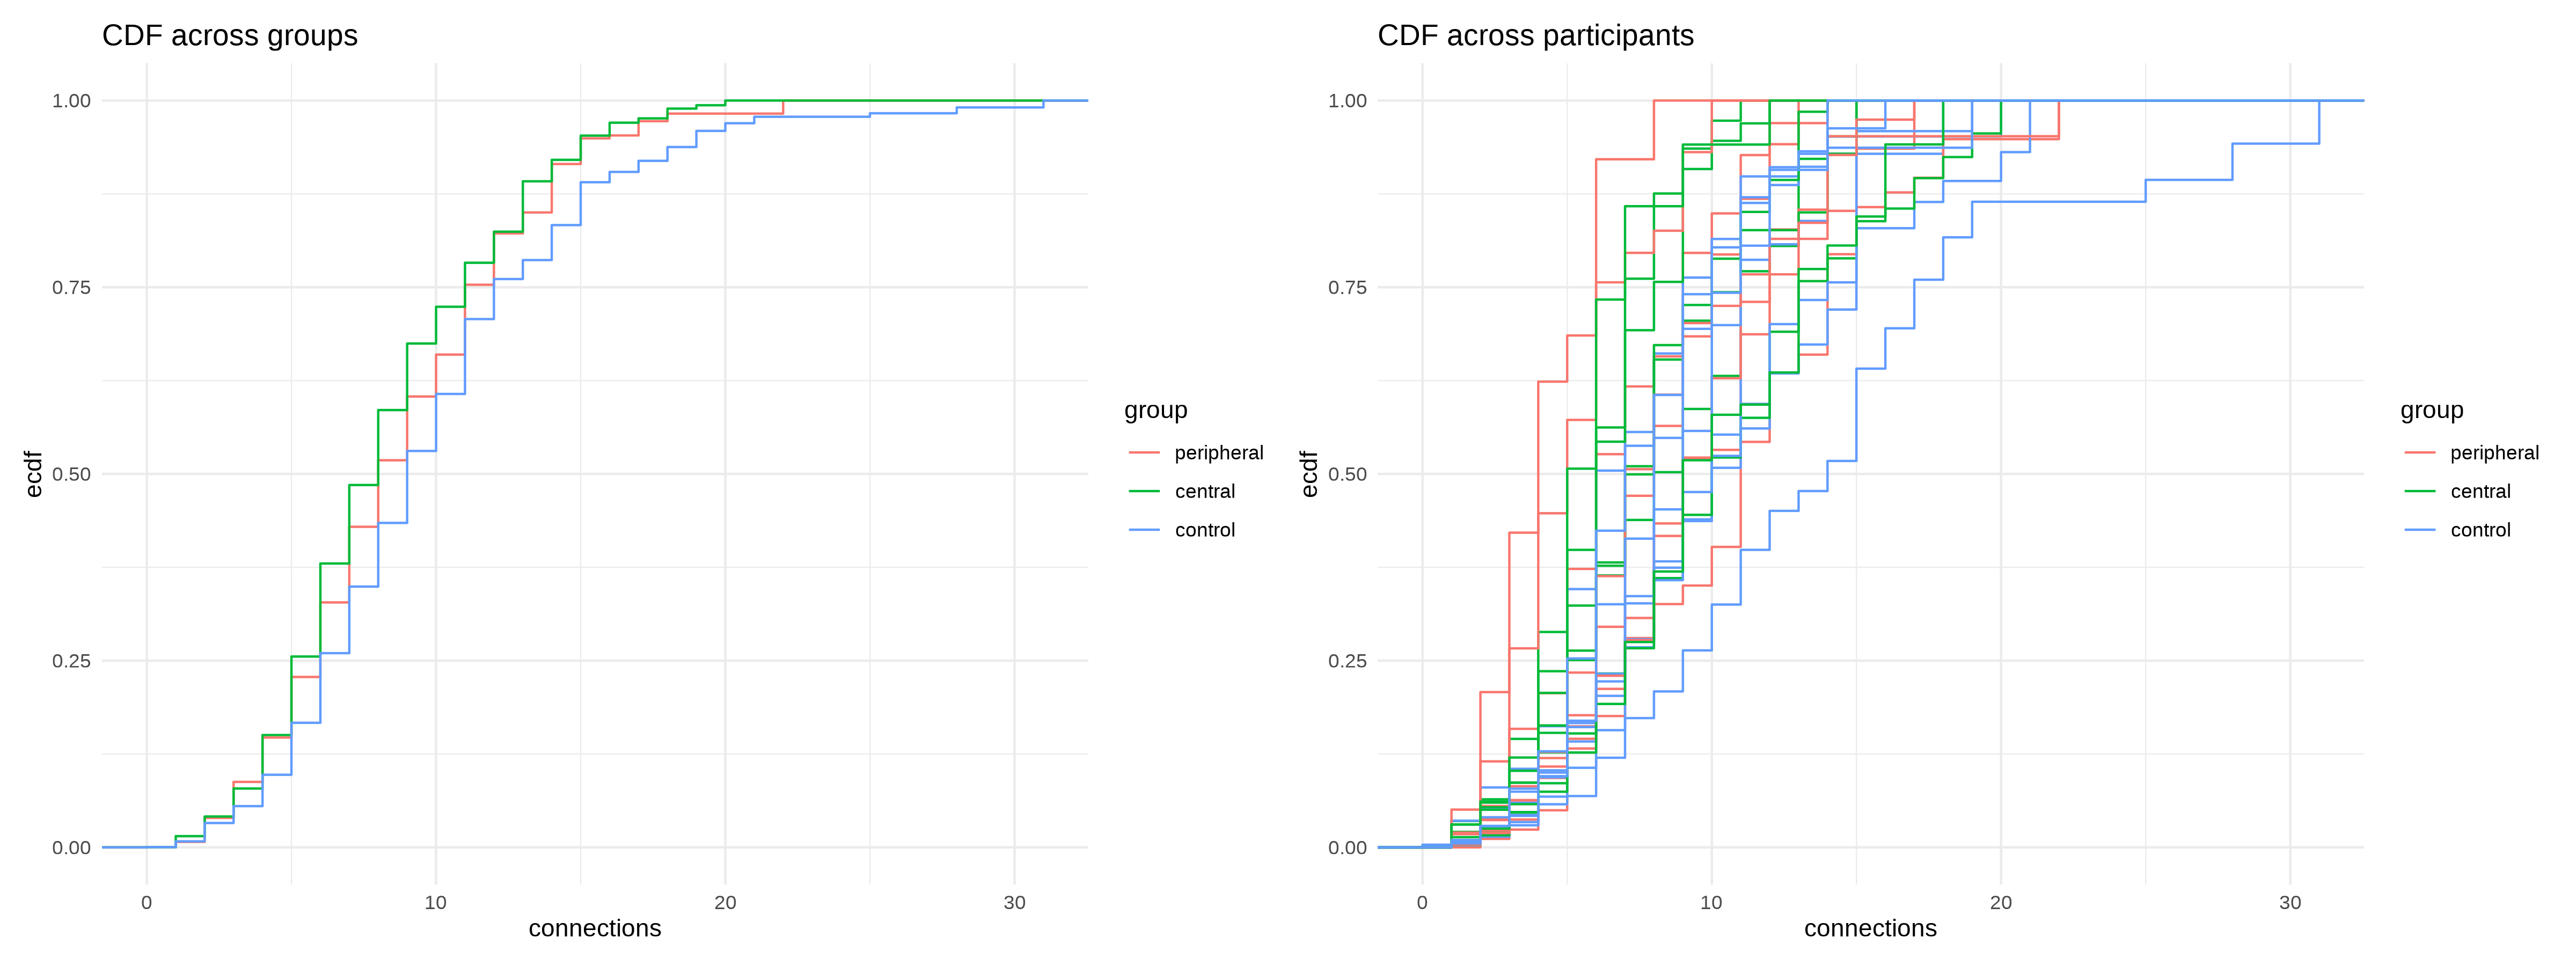

In [22]:
library(patchwork)
fig_group <- ggplot(df_node, aes(connections, group = group, color = group)) +
  stat_ecdf(geom = "step") +
  labs(title = "CDF across groups") +
  theme_minimal()
fig_participants <- ggplot(df_node, aes(connections, group = PID, color = group)) +
  stat_ecdf(geom = "step") +
  labs(title = "CDF across participants") + 
  theme_minimal()
options(repr.plot.width=16, repr.plot.height=6, repr.plot.res = 300)
fig_group | fig_participants
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)
ggsave("group_node_degree_ecdf.svg", fig_group | fig_participants, width = 16, height = 6, units = "in", dpi = 300)

In [23]:
plot_group_cdf_with_ribbon <- function(df, value_col, individual_col, group_col = NULL,
                                       probs = c(0.05, 0.95), x_points = 200) {
  # Create x grid
  x_grid <- df %>% pull({{ value_col }}) %>% range() %>%
    (\(rng) seq(rng[1], rng[2], length.out = x_points))()

  # Compute ECDFs
  ecdf_df <- df %>%
    nest(data = -c({{ group_col }}, {{ individual_col }})) %>%
    mutate(ecdf = map(data, ~ ecdf(pull(.x, {{ value_col }})))) %>%
    crossing(x = x_grid) %>%
    mutate(y = map2_dbl(ecdf, x, ~ .x(.y))) %>%
    select({{ group_col }}, {{ individual_col }}, x, y)

  # Summarize across individuals
  ecdf_summary <- ecdf_df %>%
    group_by({{ group_col }}, x) %>%
    summarize(
      ymin = quantile(y, probs[1]),
      ymax = quantile(y, probs[2]),
      ymed = median(y),
      .groups = "drop"
    )

  group_ecdf_df <- df %>%
      group_by({{ group_col }}) %>%
      summarize(data = list({{ value_col }}), .groups = "drop") %>%
      mutate(ecdf = map(data, ~ ecdf(.x))) %>%
      crossing(x = x_grid) %>%
      mutate(y = map2_dbl(ecdf, x, ~ .x(.y)))

  # Plot
  ggplot(ecdf_summary, aes(x = x, group = {{ group_col }}, fill = {{ group_col }}, color = {{ group_col }})) +
    geom_ribbon(aes(ymin = ymin, ymax = ymax), alpha = 0.3, color = NA) +
    geom_line(data = group_ecdf_df, aes(x = x, y = y, color = {{ group_col }}), size = 1) +
    theme_minimal() +
    labs(x = "node degree", y = "ECDF", title = "Group CDFs with Individual Variation",
         subtitle = paste0("Ribbon = ", probs[1]*100, "% to ", probs[2]*100, "% quantile of individuals")) +
    guides(fill = guide_legend(title = "Group"), color = guide_legend(title = "Group"))
}

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


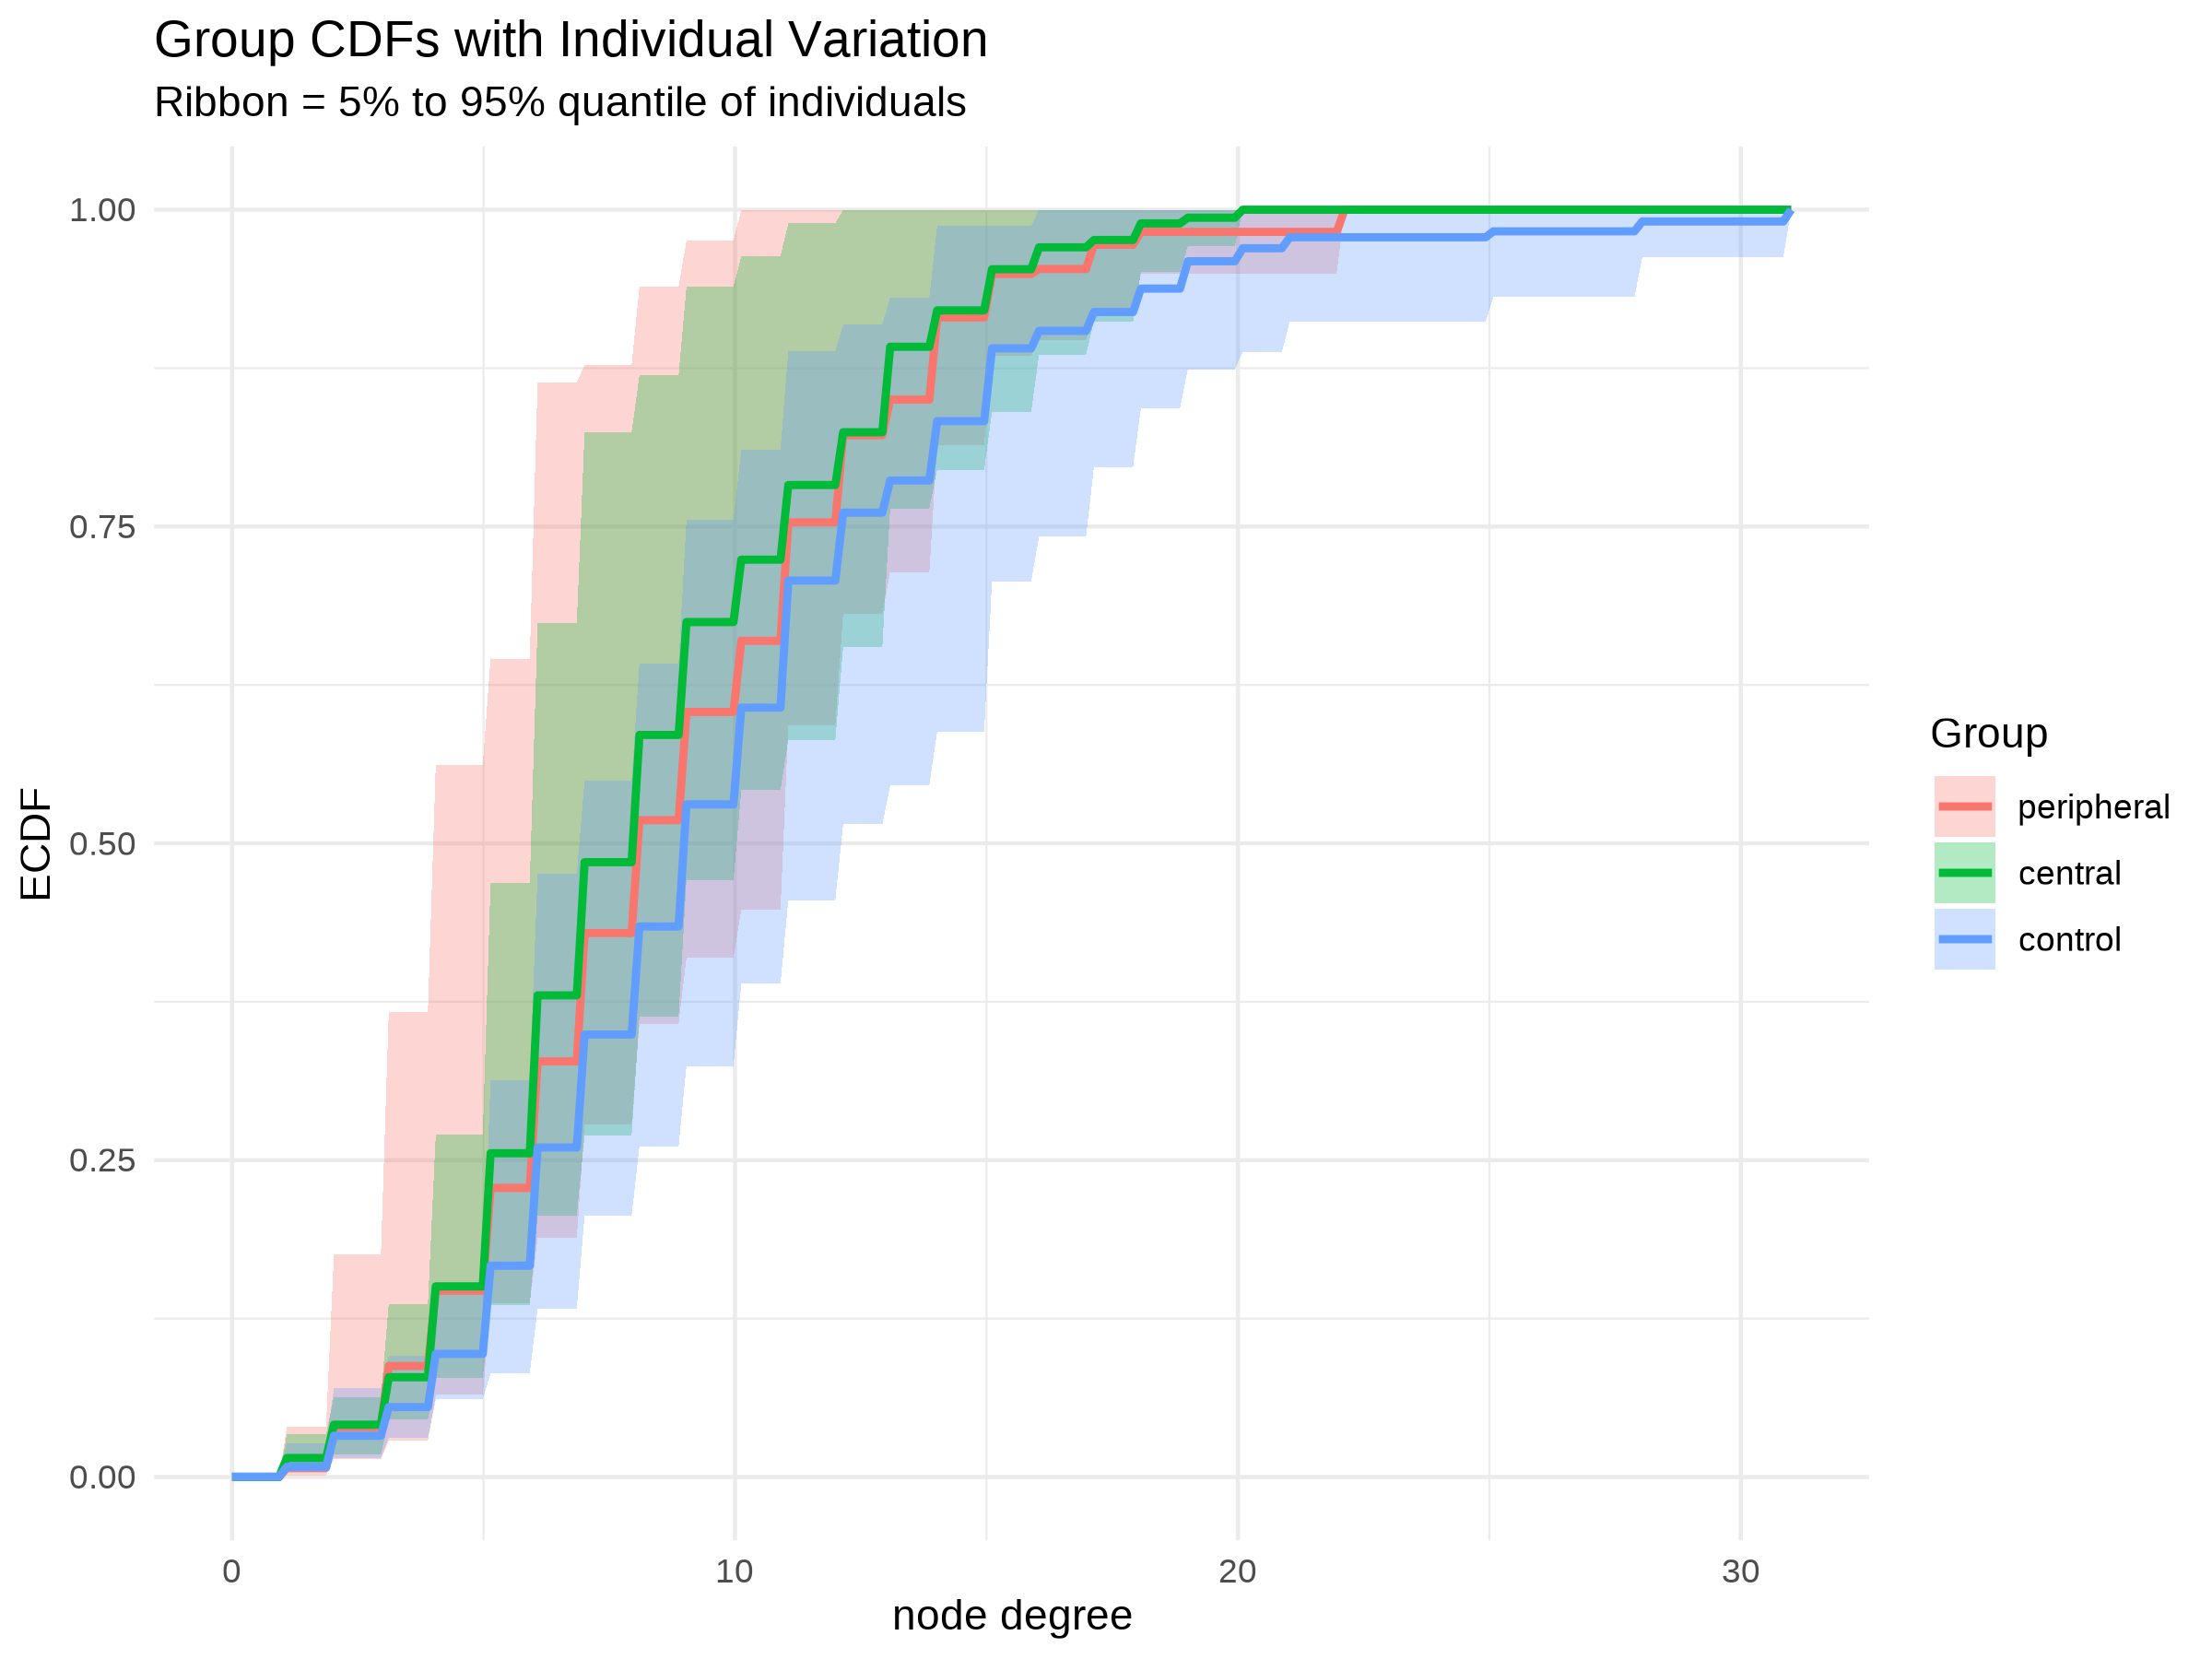

In [24]:
fig <- df_node |> plot_group_cdf_with_ribbon(connections, PID, group)
fig
# ggsave("group_node_degree_ecdf.svg", fig, width = 6, height = 6, units = "in", dpi = 300)

In [25]:
df_node |>
  ggplot(aes(x = clusterDuration)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  xlim(0,1)+
  facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
  theme_minimal() +
  labs(title = "Density Plot for Each Combination of Factors",
       x = "median cluster duration for each building (s)",
       y = "density")

ERROR while rich displaying an object: Error in `geom_density()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! object 'clusterDuration' not found

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.nul

ERROR: Error in file(con, "rb"): cannot open the connection


plot without title

In [ ]:
df <- read_csv("graph_group_connections.csv")
df <- df |> 
    mutate(
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control")),
        hitObjectColliderName = factor(hitObjectColliderName)
    ) |>
    rename(
        group = category
    )

Rows: 1826 Columns: 4
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (2): PID, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
fig <- df |>
  ggplot(aes(x = connections, group = group, color = group)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  theme_minimal() +
  labs(title = "Node degree centrality distribution",
       x = "node degree",
       y = "density")
#ggsave("sim_node_degree_dist.svg", fig)
fig

df_node |>
    group_by(PID, building, group, building_location, connections) |>
    ungroup() |>
    filter(connections > 10) |>
    ggplot(aes(x = duration)) +
      geom_density(alpha = 0.6) +  # Adjust alpha for transparency
      xlim(0,1)+
      facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
      theme_minimal() +
      labs(title = "Density Plot (node-degree > 10)",
           x = "median cluster duration for each building (s)",
           y = "density")
ggsave("naisu_only_location_node_filter.svg", fig)

Saving 6.67 x 6.67 in image


In [ ]:
df_rm_null <- df_group_node |> filter(connections > 0)

model <- glmer(connections ~  group * building_location + (1 | PID), data = df_rm_null, Gamma(link = "inverse"))

In [ ]:
# Create a reference grid
ref_grid <- ref_grid(model)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ building_location)

# View results
summary(emm)
pairs(emm, adjust = "bonferroni")
pairs(emm, adjust = "tukey")

,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,4.350301,0.1925744,Inf,3.972862,4.727740
2,inside,6.887977,0.4680248,Inf,5.970666,7.805289


 contrast         estimate    SE  df z.ratio p.value
 outside - inside    -2.54 0.311 Inf  -8.147  <.0001

Results are averaged over the levels of: group 

 contrast         estimate    SE  df z.ratio p.value
 outside - inside    -2.54 0.311 Inf  -8.147  <.0001

Results are averaged over the levels of: group 

In [ ]:
model
library(car)
Anova(model)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( inverse )
Formula: connections ~ group * building_location + (1 | PID)
   Data: df_rm_null
      AIC       BIC    logLik  deviance  df.resid 
 9238.169  9282.248 -4611.084  9222.169      1818 
Random effects:
 Groups   Name        Std.Dev.
 PID      (Intercept) 0.02747 
 Residual             0.57017 
Number of obs: 1826, groups:  PID, 24
Fixed Effects:
                         (Intercept)                          groupcentral  
                            0.237722                              0.003478  
                        groupcontrol               building_locationinside  
                           -0.024330                             -0.072348  
groupcentral:building_locationinside  groupcontrol:building_locationinside  
                           -0.017550                             -0.016438  

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
group,2.619834,2,2.698424e-01
building_location,310.818873,1,1.448236e-69
group:building_location,2.724093,2,2.561361e-01
